Universidade Federal de Santa Catarina

Departamento de Informática e Estatística

INE5664 - Aprendizado de Máquina


### Atividade Prática - Agrupamento

Uma grande rede de shopping centers coletou dados a respeito do quanto cada um de seus clientes compra usando uma métrica chamada spending score, além de outros dados individuais a respeito de cada cliente. Ela contratou a sua equipe para, com base nos dados e na aplicação de técnicas de mineração de dados, segmentar os clientes e definir qual seria o número de ideal de campanhas de marketing (segmentos) a serem criadas, e também o perfil dos clientes em cada campanha. Desta forma, utilizando técnicas de análise de agrupamentos:

1. Realize uma análise exploratória dos dados para entendê-los
2. Prepare os dados com os passos que julgar necessários
3. Realize a aplicação de técnicas de agrupamento para embasar as respostas dos próximos itens (utilize renda e spending score)
4. Defina o número mais adequado de campanhas de marketing (agrupamentos)
5. Defina o perfil de cada grupo
6. Desafio: tente utilizar a idade na análise

OBS: use o método sch.dendrogram(sch.linkage([seu_dataframe], method='ward')) para produzir e visualizar o dendograma de uma clusterização hierárquica

In [2]:
import pandas as pd
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch

df = pd.read_csv('https://codigos.ufsc.br/jonata.tyska/repositorio/-/raw/master/datasets/spending_score.csv')

# Renomear colunas para nomes mais simples
df.columns = ['CustomerID', 'Gender', 'Age', 'Annual Income', 'Spending Score']

df.head()

,CustomerID,Gender,Age,Annual Income,Spending Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
# 1. ANÁLISE EXPLORATÓRIA DOS DADOS

# Visualizar as primeiras linhas
print("Primeiras linhas do dataset:")
print(df.head(10))
print("\nForma do dataset:", df.shape)
print("\nTipos de dados:")
print(df.dtypes)
print("\nDescrição estatística:")
print(df.describe())
print("\nValores faltantes:")
print(df.isnull().sum())

Primeiras linhas do dataset:
   CustomerID  Gender  Age  Annual Income  Spending Score
0           1    Male   19             15              39
1           2    Male   21             15              81
2           3  Female   20             16               6
3           4  Female   23             16              77
4           5  Female   31             17              40
5           6  Female   22             17              76
6           7  Female   35             18               6
7           8  Female   23             18              94
8           9    Male   64             19               3
9          10  Female   30             19              72

Forma do dataset: (200, 5)

Tipos de dados:
CustomerID         int64
Gender            object
Age                int64
Annual Income      int64
Spending Score     int64
dtype: object

Descrição estatística:
       CustomerID         Age  Annual Income  Spending Score
count  200.000000  200.000000     200.000000      200.000000
mea

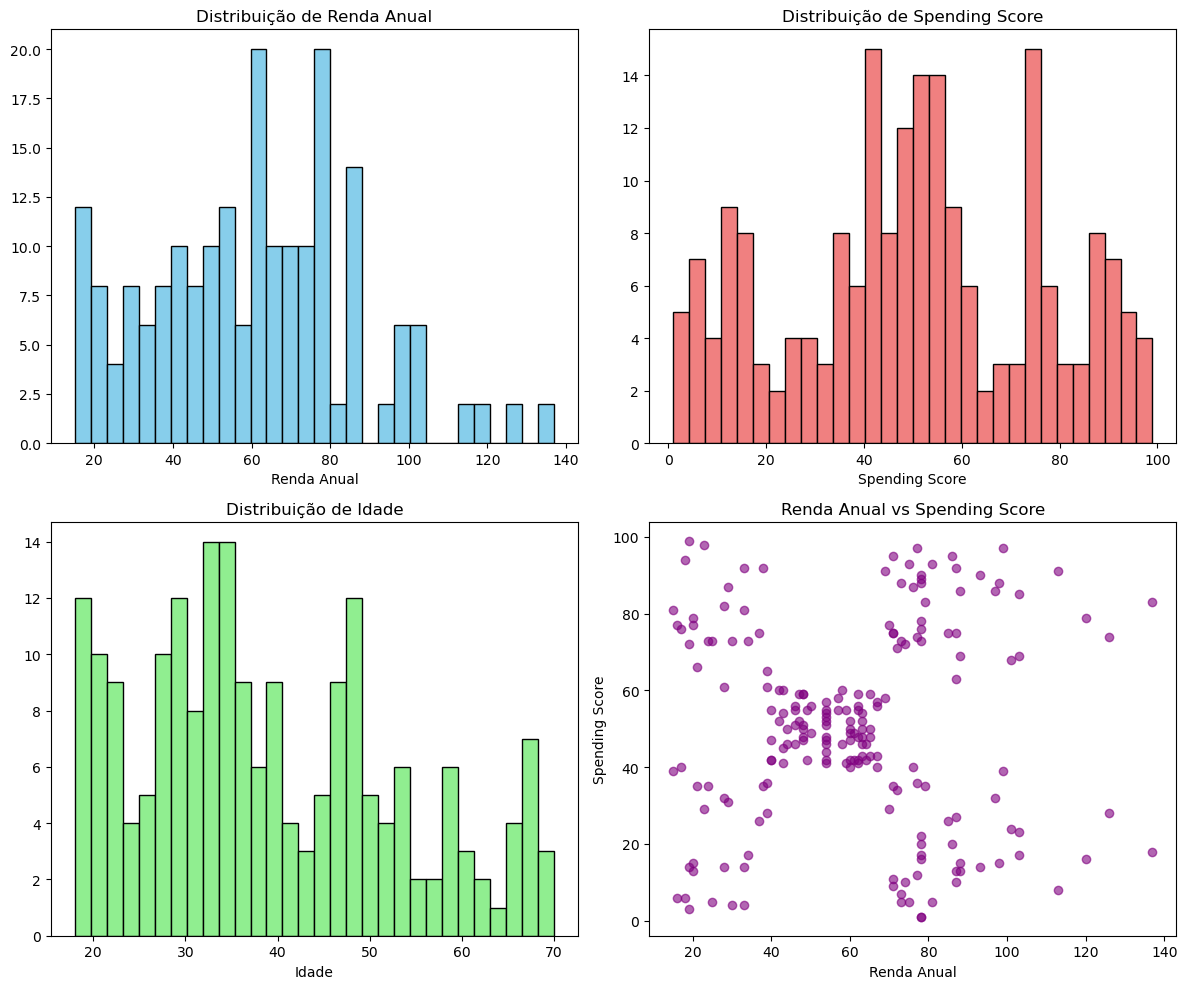


Matriz de Correlação:
                     Age  Annual Income  Spending Score
Age             1.000000      -0.012398       -0.327227
Annual Income  -0.012398       1.000000        0.009903
Spending Score -0.327227       0.009903        1.000000


In [5]:
# Visualizar distribuições das variáveis
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Distribuição de Renda
axes[0, 0].hist(df['Annual Income'], bins=30, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribuição de Renda Anual')
axes[0, 0].set_xlabel('Renda Anual')

# Distribuição de Spending Score
axes[0, 1].hist(df['Spending Score'], bins=30, color='lightcoral', edgecolor='black')
axes[0, 1].set_title('Distribuição de Spending Score')
axes[0, 1].set_xlabel('Spending Score')

# Distribuição de Idade
axes[1, 0].hist(df['Age'], bins=30, color='lightgreen', edgecolor='black')
axes[1, 0].set_title('Distribuição de Idade')
axes[1, 0].set_xlabel('Idade')

# Scatter: Renda vs Spending Score
axes[1, 1].scatter(df['Annual Income'], df['Spending Score'], alpha=0.6, color='purple')
axes[1, 1].set_title('Renda Anual vs Spending Score')
axes[1, 1].set_xlabel('Renda Anual')
axes[1, 1].set_ylabel('Spending Score')

plt.tight_layout()
plt.show()

# Matriz de correlação (apenas colunas numéricas)
print("\nMatriz de Correlação:")
print(df[['Age', 'Annual Income', 'Spending Score']].corr())

In [6]:
# 2. PREPARAÇÃO DOS DADOS

from sklearn.preprocessing import StandardScaler

# Selecionar as variáveis de interesse: Renda e Spending Score
X = df[['Annual Income', 'Spending Score']].copy()

# Normalizar os dados (necessário para K-means e clustering hierárquico)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Dados originais (primeiras linhas):")
print(X.head())
print("\nDados normalizados (primeiras linhas):")
print(X_scaled[:5])
print("\nDados escalados têm média 0 e desvio padrão 1:")
print(f"Média: {X_scaled.mean(axis=0)}")
print(f"Desvio padrão: {X_scaled.std(axis=0)}")

Dados originais (primeiras linhas):
   Annual Income  Spending Score
0             15              39
1             15              81
2             16               6
3             16              77
4             17              40

Dados normalizados (primeiras linhas):
[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]

Dados escalados têm média 0 e desvio padrão 1:
Média: [-2.13162821e-16 -1.46549439e-16]
Desvio padrão: [1. 1.]


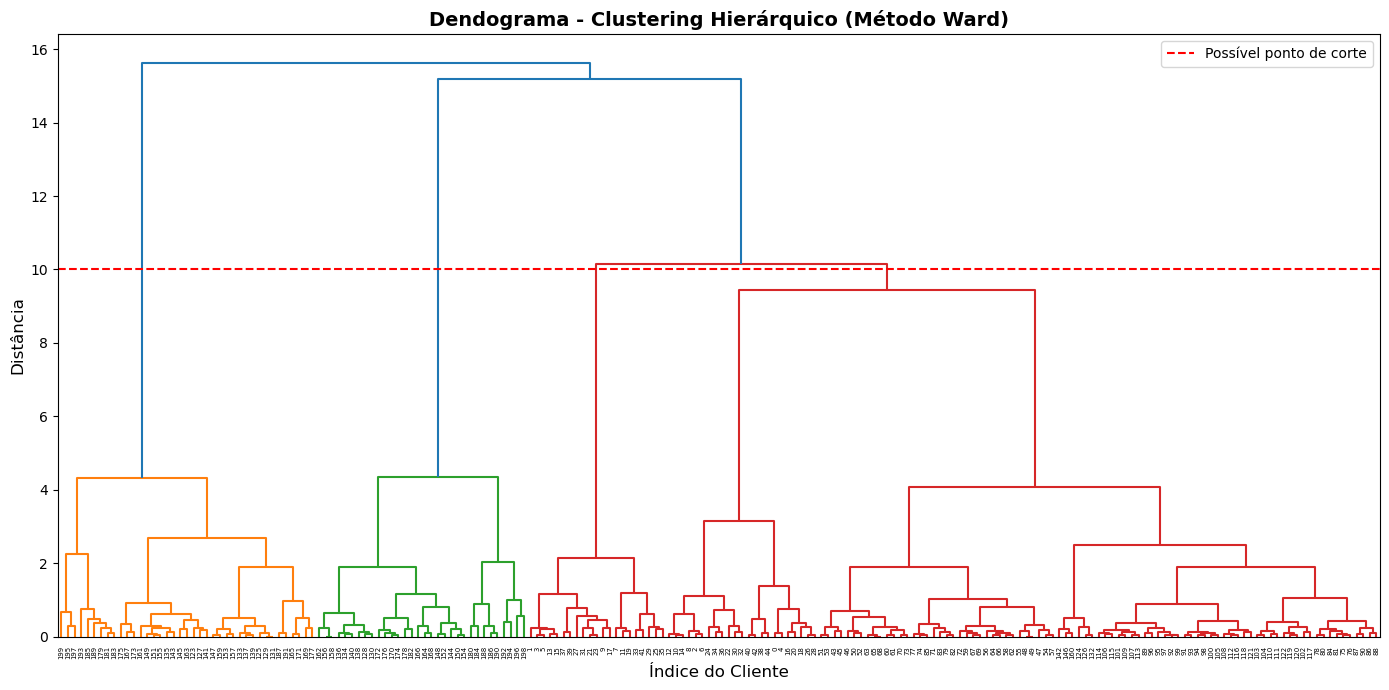


O dendograma mostra como os clientes são agrupados hierarquicamente.
A altura da linha de corte indica quantos clusters devemos formar.


In [7]:
# 3. CLUSTERING HIERÁRQUICO E DENDOGRAMA

# Criar o dendograma usando método Ward
plt.figure(figsize=(14, 7))
dendogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title('Dendograma - Clustering Hierárquico (Método Ward)', fontsize=14, fontweight='bold')
plt.xlabel('Índice do Cliente', fontsize=12)
plt.ylabel('Distância', fontsize=12)
plt.axhline(y=10, color='r', linestyle='--', label='Possível ponto de corte')
plt.legend()
plt.tight_layout()
plt.show()

print("\nO dendograma mostra como os clientes são agrupados hierarquicamente.")
print("A altura da linha de corte indica quantos clusters devemos formar.")

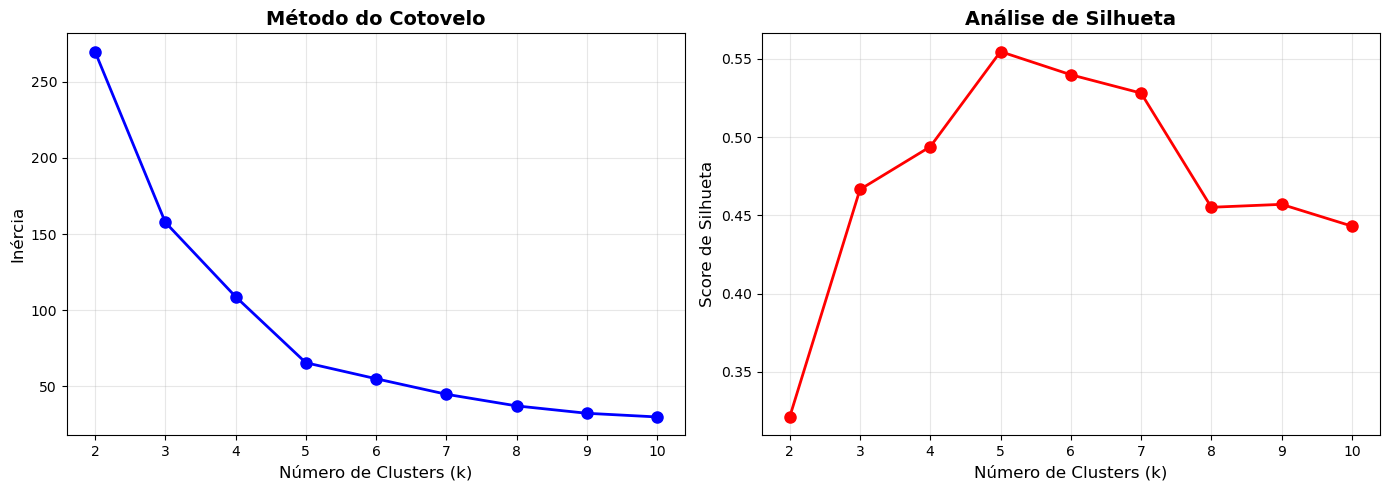


Análise dos números de clusters:
k=2: Inércia=269.69, Silhueta=0.3213
k=3: Inércia=157.70, Silhueta=0.4666
k=4: Inércia=108.92, Silhueta=0.4939
k=5: Inércia=65.57, Silhueta=0.5547
k=6: Inércia=55.06, Silhueta=0.5399
k=7: Inércia=44.86, Silhueta=0.5281
k=8: Inércia=37.23, Silhueta=0.4552
k=9: Inércia=32.39, Silhueta=0.4571
k=10: Inércia=29.98, Silhueta=0.4432


In [8]:
# 4. DETERMINAÇÃO DO NÚMERO IDEAL DE CLUSTERS - MÉTODO DO COTOVELO

from sklearn.cluster import KMeans

# Testar diferentes números de clusters
inertias = []
silhouette_scores = []
K_range = range(2, 11)

from sklearn.metrics import silhouette_score

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plotar o método do cotovelo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico da inércia
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Número de Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inércia', fontsize=12)
axes[0].set_title('Método do Cotovelo', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Gráfico do Silhueta
axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Número de Clusters (k)', fontsize=12)
axes[1].set_ylabel('Score de Silhueta', fontsize=12)
axes[1].set_title('Análise de Silhueta', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nAnálise dos números de clusters:")
for k, inertia, sil_score in zip(K_range, inertias, silhouette_scores):
    print(f"k={k}: Inércia={inertia:.2f}, Silhueta={sil_score:.4f}")

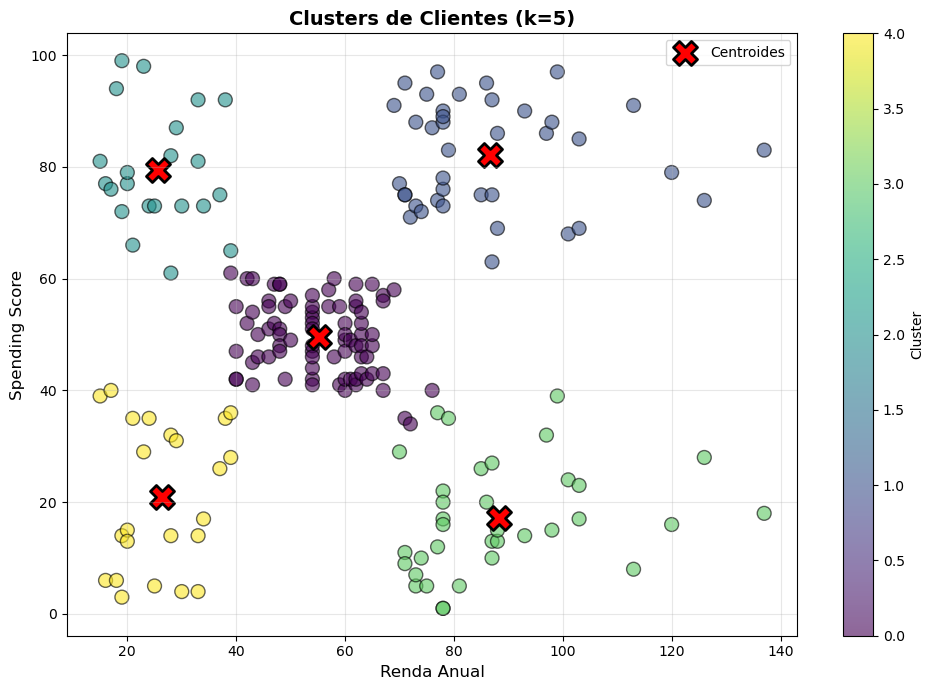


Número de clientes por cluster:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


In [9]:
# Baseado na análise, vamos usar k=5 como número ideal de clusters
optimal_k = 5

# Treinar K-means com o número ótimo de clusters
kmeans_optimal = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans_optimal.fit_predict(X_scaled)

# Adicionar os clusters ao dataframe original
df['Cluster'] = clusters

# Visualizar os clusters
plt.figure(figsize=(10, 7))
scatter = plt.scatter(df['Annual Income'], df['Spending Score'], 
                     c=clusters, cmap='viridis', s=100, alpha=0.6, edgecolors='black')
plt.scatter(scaler.inverse_transform(kmeans_optimal.cluster_centers_)[:, 0],
           scaler.inverse_transform(kmeans_optimal.cluster_centers_)[:, 1],
           c='red', marker='X', s=300, edgecolors='black', linewidth=2, label='Centroides')
plt.xlabel('Renda Anual', fontsize=12)
plt.ylabel('Spending Score', fontsize=12)
plt.title(f'Clusters de Clientes (k={optimal_k})', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nNúmero de clientes por cluster:")
print(df['Cluster'].value_counts().sort_index())

In [10]:
# 5. ANÁLISE DE PERFIL DE CADA GRUPO

print("="*70)
print("PERFIL DE CADA GRUPO/CAMPANHA DE MARKETING")
print("="*70)

for cluster_id in range(optimal_k):
    cluster_data = df[df['Cluster'] == cluster_id]
    
    print(f"\n{'='*70}")
    print(f"CLUSTER {cluster_id} - {len(cluster_data)} clientes")
    print(f"{'='*70}")
    
    print(f"\nRenda Anual:")
    print(f"  Média: R$ {cluster_data['Annual Income'].mean():.2f}")
    print(f"  Min: R$ {cluster_data['Annual Income'].min():.2f}")
    print(f"  Max: R$ {cluster_data['Annual Income'].max():.2f}")
    print(f"  Desvio Padrão: R$ {cluster_data['Annual Income'].std():.2f}")
    
    print(f"\nSpending Score:")
    print(f"  Média: {cluster_data['Spending Score'].mean():.2f}")
    print(f"  Min: {cluster_data['Spending Score'].min():.2f}")
    print(f"  Max: {cluster_data['Spending Score'].max():.2f}")
    print(f"  Desvio Padrão: {cluster_data['Spending Score'].std():.2f}")
    
    print(f"\nIdade:")
    print(f"  Média: {cluster_data['Age'].mean():.2f} anos")
    print(f"  Min: {cluster_data['Age'].min()} anos")
    print(f"  Max: {cluster_data['Age'].max()} anos")
    
    # Definir rótulo do grupo
    renda_media = cluster_data['Annual Income'].mean()
    spending_media = cluster_data['Spending Score'].mean()
    
    if renda_media > df['Annual Income'].mean() and spending_media > df['Spending Score'].mean():
        perfil = "👑 Clientes Premium (alta renda, alto gasto)"
    elif renda_media > df['Annual Income'].mean() and spending_media < df['Spending Score'].mean():
        perfil = "💰 Clientes Conservadores (alta renda, baixo gasto)"
    elif renda_media < df['Annual Income'].mean() and spending_media > df['Spending Score'].mean():
        perfil = "🛍️ Clientes Consumidores (baixa renda, alto gasto)"
    else:
        perfil = "📊 Clientes Econômicos (baixa renda, baixo gasto)"
    
    print(f"\n📌 Perfil: {perfil}")

PERFIL DE CADA GRUPO/CAMPANHA DE MARKETING

CLUSTER 0 - 81 clientes

Renda Anual:
  Média: R$ 55.30
  Min: R$ 39.00
  Max: R$ 76.00
  Desvio Padrão: R$ 8.99

Spending Score:
  Média: 49.52
  Min: 34.00
  Max: 61.00
  Desvio Padrão: 6.53

Idade:
  Média: 42.72 anos
  Min: 18 anos
  Max: 70 anos

📌 Perfil: 📊 Clientes Econômicos (baixa renda, baixo gasto)

CLUSTER 1 - 39 clientes

Renda Anual:
  Média: R$ 86.54
  Min: R$ 69.00
  Max: R$ 137.00
  Desvio Padrão: R$ 16.31

Spending Score:
  Média: 82.13
  Min: 63.00
  Max: 97.00
  Desvio Padrão: 9.36

Idade:
  Média: 32.69 anos
  Min: 27 anos
  Max: 40 anos

📌 Perfil: 👑 Clientes Premium (alta renda, alto gasto)

CLUSTER 2 - 22 clientes

Renda Anual:
  Média: R$ 25.73
  Min: R$ 15.00
  Max: R$ 39.00
  Desvio Padrão: R$ 7.57

Spending Score:
  Média: 79.36
  Min: 61.00
  Max: 99.00
  Desvio Padrão: 10.50

Idade:
  Média: 25.27 anos
  Min: 18 anos
  Max: 35 anos

📌 Perfil: 🛍️ Clientes Consumidores (baixa renda, alto gasto)

CLUSTER 3 - 35 clien


DESAFIO - CLUSTERING COM INCLUSÃO DE IDADE


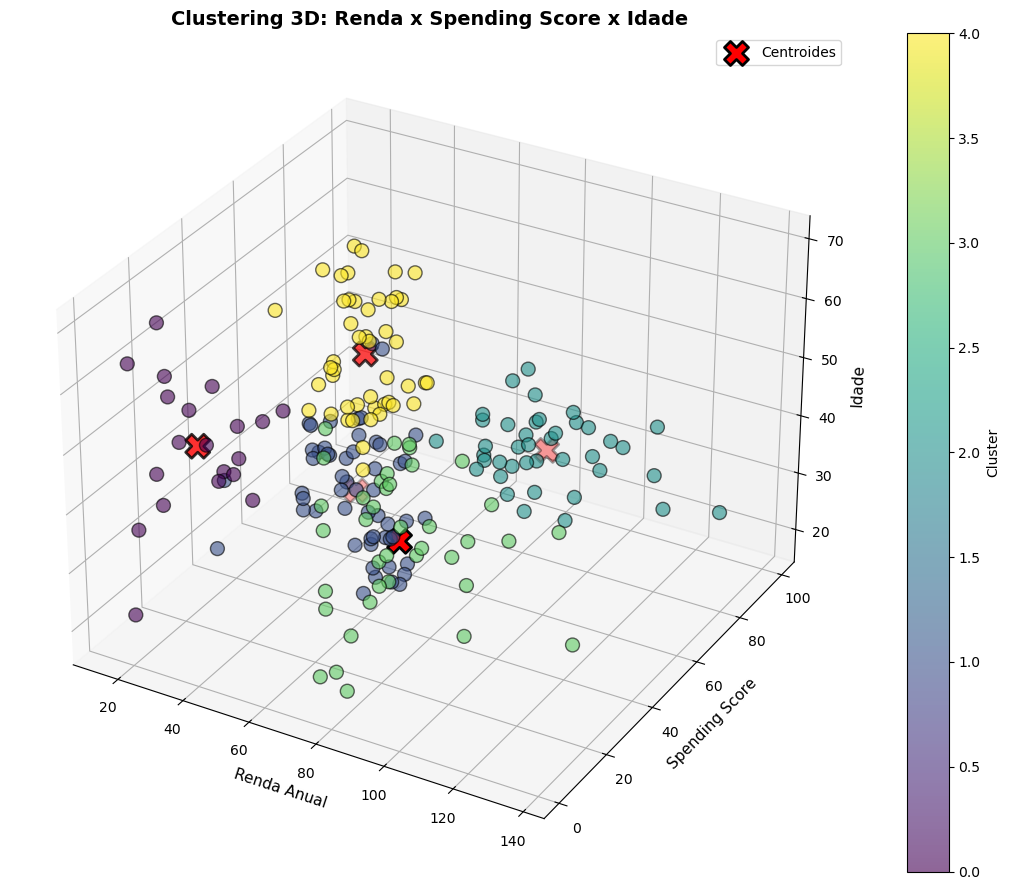


Comparação entre clustering 2D e 3D:
Silhueta (2D com Renda e Spending Score): 0.5547
Silhueta (3D com Renda, Spending Score e Idade): 0.4166

Número de mudanças de cluster entre 2D e 3D:
Total de clientes que mudaram de cluster: 165
Percentual de mudança: 82.50%


In [11]:
# 6. DESAFIO - ANÁLISE INCLUINDO IDADE

print("\n" + "="*70)
print("DESAFIO - CLUSTERING COM INCLUSÃO DE IDADE")
print("="*70)

# Selecionar três variáveis: Renda, Spending Score e Idade
X_3d = df[['Annual Income', 'Spending Score', 'Age']].copy()

# Normalizar os dados
X_3d_scaled = scaler.fit_transform(X_3d)

# Aplicar K-means com 3 dimensões
kmeans_3d = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters_3d = kmeans_3d.fit_predict(X_3d_scaled)

# Adicionar os novos clusters ao dataframe
df['Cluster_3D'] = clusters_3d

# Visualizar em 3D usando matplotlib
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Plotar os pontos coloridos por cluster
scatter = ax.scatter(df['Annual Income'], df['Spending Score'], df['Age'],
                    c=clusters_3d, cmap='viridis', s=100, alpha=0.6, edgecolors='black')

# Plotar os centroides
centroides_3d = scaler.inverse_transform(kmeans_3d.cluster_centers_)
ax.scatter(centroides_3d[:, 0], centroides_3d[:, 1], centroides_3d[:, 2],
          c='red', marker='X', s=300, edgecolors='black', linewidth=2, label='Centroides')

ax.set_xlabel('Renda Anual', fontsize=11)
ax.set_ylabel('Spending Score', fontsize=11)
ax.set_zlabel('Idade', fontsize=11)
ax.set_title('Clustering 3D: Renda x Spending Score x Idade', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Cluster', ax=ax)
plt.legend()
plt.tight_layout()
plt.show()

print("\nComparação entre clustering 2D e 3D:")
print(f"Silhueta (2D com Renda e Spending Score): {silhouette_score(X_scaled, clusters):.4f}")
print(f"Silhueta (3D com Renda, Spending Score e Idade): {silhouette_score(X_3d_scaled, clusters_3d):.4f}")

# Mostrar matriz de comparação dos clusters
comparison = pd.DataFrame({
    'Cluster_2D': clusters,
    'Cluster_3D': clusters_3d
})
print("\nNúmero de mudanças de cluster entre 2D e 3D:")
print(f"Total de clientes que mudaram de cluster: {(clusters != clusters_3d).sum()}")
print(f"Percentual de mudança: {(clusters != clusters_3d).sum() / len(df) * 100:.2f}%")

## CONCLUSÕES

### 1. Análise Exploratória
- O dataset contém informações de clientes com variáveis de renda e spending score
- As distribuições mostram que há clientes com diversos perfis de consumo

### 2. Preparação de Dados
- Os dados foram normalizados usando StandardScaler para garantir que todas as variáveis tenham a mesma escala
- Isso é essencial para algoritmos baseados em distância como K-means

### 3. Técnicas de Agrupamento
- **Clustering Hierárquico**: O dendograma ajuda a visualizar a estrutura hierárquica dos dados
- **K-means**: Aplicado para particionar os dados em grupos

### 4. Número Ideal de Clusters
- O método do cotovelo e o score de silhueta indicam que **k=5** é um bom número de clusters
- Isso significa que a rede de shopping centers deve criar **5 campanhas de marketing distintas**

### 5.Perfil dos Grupos
- Cada grupo possui características distintas de renda e hábito de gastos
- Permitem estratégias de marketing personalizadas

### 6. Desafio - Inclusão de Idade
- Quando incluímos idade na análise (clustering 3D), observamos mudanças nos agrupamentos
- Isso indica que a idade é uma variável importante para segmentação
- A comparação da silhueta mostra o impacto de incluir mais dimensões na análise